In [1]:
print('hello')

hello


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
# Fix the path
df = pd.read_csv(r"Expanded_data_with_more_features.csv", encoding="utf-8")

print(df.head())  # shows first 5 rows


   Unnamed: 0  Gender EthnicGroup          ParentEduc     LunchType TestPrep  \
0           0  female         NaN   bachelor's degree      standard     none   
1           1  female     group C        some college      standard      NaN   
2           2  female     group B     master's degree      standard     none   
3           3    male     group A  associate's degree  free/reduced     none   
4           4    male     group C        some college      standard     none   

  ParentMaritalStatus PracticeSport IsFirstChild  NrSiblings TransportMeans  \
0             married     regularly          yes         3.0     school_bus   
1             married     sometimes          yes         0.0            NaN   
2              single     sometimes          yes         4.0     school_bus   
3             married         never           no         1.0            NaN   
4             married     sometimes          yes         0.0     school_bus   

  WklyStudyHours  MathScore  ReadingScore  W

In [5]:
# Describe data
print(df.describe())


         Unnamed: 0    NrSiblings     MathScore  ReadingScore  WritingScore
count  30641.000000  29069.000000  30641.000000  30641.000000  30641.000000
mean     499.556607      2.145894     66.558402     69.377533     68.418622
std      288.747894      1.458242     15.361616     14.758952     15.443525
min        0.000000      0.000000      0.000000     10.000000      4.000000
25%      249.000000      1.000000     56.000000     59.000000     58.000000
50%      500.000000      2.000000     67.000000     70.000000     69.000000
75%      750.000000      3.000000     78.000000     80.000000     79.000000
max      999.000000      7.000000    100.000000    100.000000    100.000000


In [6]:
# information method 
df.info()
print(df)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           30641 non-null  int64  
 1   Gender               30641 non-null  object 
 2   EthnicGroup          28801 non-null  object 
 3   ParentEduc           28796 non-null  object 
 4   LunchType            30641 non-null  object 
 5   TestPrep             28811 non-null  object 
 6   ParentMaritalStatus  29451 non-null  object 
 7   PracticeSport        30010 non-null  object 
 8   IsFirstChild         29737 non-null  object 
 9   NrSiblings           29069 non-null  float64
 10  TransportMeans       27507 non-null  object 
 11  WklyStudyHours       29686 non-null  object 
 12  MathScore            30641 non-null  int64  
 13  ReadingScore         30641 non-null  int64  
 14  WritingScore         30641 non-null  int64  
dtypes: float64(1), int64(4), object(10)


In [7]:
#how many value is null 
df.isnull().sum()
print(df)

       Unnamed: 0  Gender EthnicGroup          ParentEduc     LunchType  \
0               0  female         NaN   bachelor's degree      standard   
1               1  female     group C        some college      standard   
2               2  female     group B     master's degree      standard   
3               3    male     group A  associate's degree  free/reduced   
4               4    male     group C        some college      standard   
...           ...     ...         ...                 ...           ...   
30636         816  female     group D         high school      standard   
30637         890    male     group E         high school      standard   
30638         911  female         NaN         high school  free/reduced   
30639         934  female     group D  associate's degree      standard   
30640         960    male     group B        some college      standard   

        TestPrep ParentMaritalStatus PracticeSport IsFirstChild  NrSiblings  \
0           none    

In [8]:
#delete row column
df = df.drop(columns=['Unnamed: 0'])
print(df) 


       Gender EthnicGroup          ParentEduc     LunchType   TestPrep  \
0      female         NaN   bachelor's degree      standard       none   
1      female     group C        some college      standard        NaN   
2      female     group B     master's degree      standard       none   
3        male     group A  associate's degree  free/reduced       none   
4        male     group C        some college      standard       none   
...       ...         ...                 ...           ...        ...   
30636  female     group D         high school      standard       none   
30637    male     group E         high school      standard       none   
30638  female         NaN         high school  free/reduced  completed   
30639  female     group D  associate's degree      standard  completed   
30640    male     group B        some college      standard       none   

      ParentMaritalStatus PracticeSport IsFirstChild  NrSiblings  \
0                 married     regularly    

In [9]:
# Fix str.replace usage
df['WklyStudyHours'] = df['WklyStudyHours'].astype(str).str.replace('05-Oct', '5-10')
df.head()

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75


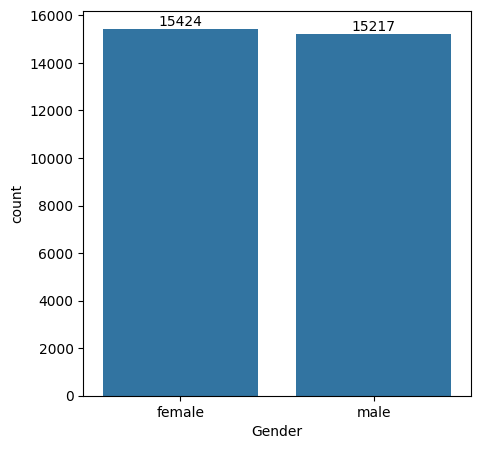

In [10]:
## Gender count plot
plt.figure(figsize = (5,5))
ax = sns.countplot(data = df, x= "Gender" )
ax.bar_label(ax.containers[0])
plt.show()

In [11]:
#from the above chart we have analyzed that the number of females in the data is the more than the males

In [12]:

gb = df.groupby('ParentEduc').agg({
    "MathScore": "mean",
    "ReadingScore": "mean",
    "WritingScore": "mean"
})
print(gb)

                    MathScore  ReadingScore  WritingScore
ParentEduc                                               
associate's degree  68.365586     71.124324     70.299099
bachelor's degree   70.466627     73.062020     73.331069
high school         64.435731     67.213997     65.421136
master's degree     72.336134     75.832921     76.356896
some college        66.390472     69.179708     68.501432
some high school    62.584013     65.510785     63.632409


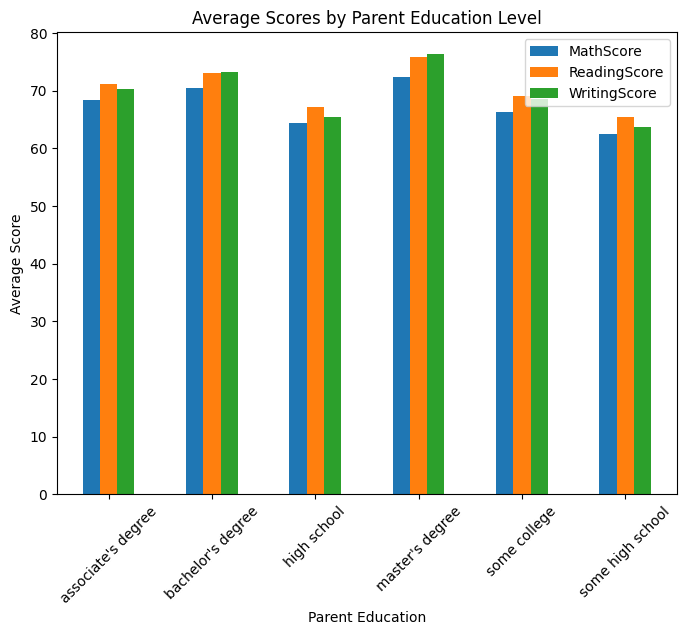

In [13]:
import matplotlib.pyplot as plt

# Plot average scores by Parent Education
gb.plot(kind="bar", figsize=(8,6))
plt.title("Average Scores by Parent Education Level")
plt.ylabel("Average Score")
plt.xlabel("Parent Education")
plt.xticks(rotation=45)
plt.show()


In [14]:
print(gb.sort_values("MathScore", ascending=False))



                    MathScore  ReadingScore  WritingScore
ParentEduc                                               
master's degree     72.336134     75.832921     76.356896
bachelor's degree   70.466627     73.062020     73.331069
associate's degree  68.365586     71.124324     70.299099
some college        66.390472     69.179708     68.501432
high school         64.435731     67.213997     65.421136
some high school    62.584013     65.510785     63.632409


In [15]:
# Compare average scores across subjects
gb["TotalScore"] = gb["MathScore"] + gb["ReadingScore"] + gb["WritingScore"]
gb["OverallAverage"] = gb["TotalScore"] / 3

print(gb[["MathScore", "ReadingScore", "WritingScore", "OverallAverage"]])


                    MathScore  ReadingScore  WritingScore  OverallAverage
ParentEduc                                                               
associate's degree  68.365586     71.124324     70.299099       69.929670
bachelor's degree   70.466627     73.062020     73.331069       72.286572
high school         64.435731     67.213997     65.421136       65.690288
master's degree     72.336134     75.832921     76.356896       74.841984
some college        66.390472     69.179708     68.501432       68.023871
some high school    62.584013     65.510785     63.632409       63.909069


In [16]:
# High-level insights from grouped data
top_math = gb["MathScore"].idxmax()
top_reading = gb["ReadingScore"].idxmax()
top_writing = gb["WritingScore"].idxmax()
top_overall = gb["OverallAverage"].idxmax()

print("📊 High-Level Insights:")
print(f"- Highest Math average: {top_math}")
print(f"- Highest Reading average: {top_reading}")
print(f"- Highest Writing average: {top_writing}")
print(f"- Best overall performance: {top_overall}")


📊 High-Level Insights:
- Highest Math average: master's degree
- Highest Reading average: master's degree
- Highest Writing average: master's degree
- Best overall performance: master's degree


<Axes: >

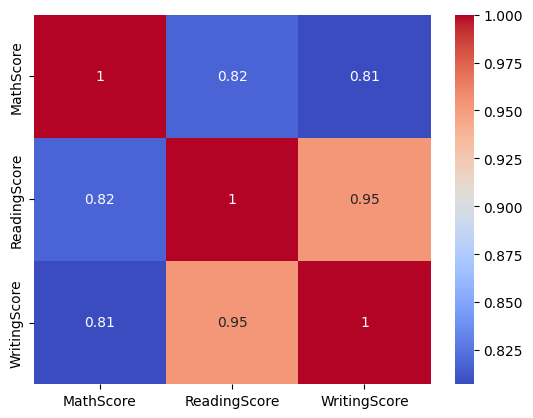

In [17]:
import seaborn as sns
sns.heatmap(df[["MathScore","ReadingScore","WritingScore"]].corr(), annot=True, cmap="coolwarm")


In [18]:
print(gb.sort_values("OverallAverage", ascending=False))


                    MathScore  ReadingScore  WritingScore  TotalScore  \
ParentEduc                                                              
master's degree     72.336134     75.832921     76.356896  224.525952   
bachelor's degree   70.466627     73.062020     73.331069  216.859716   
associate's degree  68.365586     71.124324     70.299099  209.789009   
some college        66.390472     69.179708     68.501432  204.071612   
high school         64.435731     67.213997     65.421136  197.070863   
some high school    62.584013     65.510785     63.632409  191.727207   

                    OverallAverage  
ParentEduc                          
master's degree          74.841984  
bachelor's degree        72.286572  
associate's degree       69.929670  
some college             68.023871  
high school              65.690288  
some high school         63.909069  
